In [1]:
import xradar as xd
import sys
import wradlib as wrl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import cmap
from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    generic_filter,
    uniform_filter,
    label,
)

In [2]:
# PLOTERS
###############################################################################

def plot_features(ax):
    departments = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        edgecolor='black',
        facecolor='never',
        linewidth=0.6,
        linestyle='-'
    )
    ax.add_feature(departments, zorder=3)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
    # Optional: add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

In [3]:
# HELPERS
###############################################################################

def texture_std(x):

    valid = np.isfinite(x)

    if np.sum(valid) < 3:
        return np.nan

    return np.nanstd(x)

def compute_texture(field, size=(1, 5)):
    """
    Compute local texture of a radar field.
    """

    arr = field.values.copy()

    tex = generic_filter(
        arr,
        texture_std,
        size=size,
        mode="nearest"
    )

    return xr.DataArray(
        tex,
        dims=field.dims,
        coords=field.coords
    )

In [304]:
filepath = "data/raw/Bogota/2024/10/22/1399BOG-20241022-000137-PPIVol-7244.nc"
dtree = xd.io.open_cfradial1_datatree(filepath, decode_times=False)

swp = dtree["/sweep_0"]
print(swp)

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:                          (sweep: 1, frequency: 1, azimuth: 1560,
                                          range: 960)
    Coordinates:
      * azimuth                          (azimuth) float32 6kB 0.05768 ... 359.8
        time                             (azimuth) float64 12kB 33.0 33.0 ... 33.0
        elevation                        (azimuth) float32 6kB ...
      * range                            (range) float32 4kB 31.25 ... 5.997e+04
        latitude                         float64 8B ...
        longitude                        float64 8B ...
        altitude                         float64 8B ...
    Inherited coordinates:
      * frequency                        (frequency) float32 4B 9.3e+09
    Dimensions without coordinates: sweep
    Data variables: (12/31)
        radar_measured_transmit_power_h  (azimuth) float32 6kB ...
        radar_measured_transmit_power_v  (azimuth) float32 6kB ...
        pulse_width  

In [305]:
alpha=0.01
rhohv_thresh=0.85
snr_thresh=8
ncp_thresh=0.3
texture_thresh=3
zdr_thresh=7

In [306]:
###########################################################################
# VARIABLES
###########################################################################
DBZH = swp["DBZH"]
PHIDP = swp["PHIDP"]
KDP = swp["KDP"]
RHOHV = swp["RHOHV"]
NCP = xr.ufuncs.minimum(
    swp["NCPH"],
    swp["NCPV"]
)
SNR = xr.ufuncs.minimum(
    swp["SNRHC"],
    swp["SNRVC"]
)
ZDR = swp["ZDR"]


In [307]:
###########################################################################
# 1. METEOROLOGICAL MASK
###########################################################################

met_mask = (
      (RHOHV > rhohv_thresh)
    & (SNR > snr_thresh)
    #& (NCP > ncp_thresh) 
    & (DBZH > 0)
)

In [308]:
###########################################################################
# 2. REMOVE ISOLATED PIXELS
###########################################################################

#density = uniform_filter(
#    met_mask.astype(float),
#    size=(3,5)
#)

#met_mask = density > 0.5

mask_vals = met_mask.values.copy()

labels, num = label(mask_vals)

sizes = np.bincount(labels.ravel())

min_size = 3

small = sizes < min_size

# Preserve background
small[0] = False

remove_mask = small[labels]

mask_vals[remove_mask] = False

met_mask = xr.DataArray(
    mask_vals,
    dims=met_mask.dims,
    coords=met_mask.coords
)

In [309]:
###########################################################################
# 3. FILTER REFLECTIVITY
###########################################################################

cDBZH = xr.where(
    met_mask,
    DBZH,
    np.nan
)

In [310]:
###########################################################################
# 4. INITIAL PHIDP SMOOTHING
###########################################################################

phidp = PHIDP

# 1. interpolate gaps
phidp = phidp.interpolate_na(
    dim="range",
    method="linear",
    limit=10
)

# 2. running median
phidp_vals = median_filter(
    phidp.values,
    size=(1,5)
)

sPHIDP = xr.DataArray(
    phidp_vals,
    dims=phidp.dims,
    coords=phidp.coords
)

# 4. radial running mean
#sPHIDP = sPHIDP.rolling(
#    range=25,
#    center=True
#).mean()

In [340]:
###########################################################################
# 5. PHIDP TEXTURE
###########################################################################

tPHIDP = compute_texture(
    sPHIDP,
    size=(1,5)
)

In [311]:
###########################################################################
# 6. PHIDP QUALITY MASK
###########################################################################

phi_mask = (
       met_mask
    #& (tPHIDP < texture_thresh)
)

In [312]:
###########################################################################
# 7. FILTERED PHIDP
###########################################################################

fPHIDP = xr.where(
    phi_mask,
    sPHIDP,
    np.nan
)

In [313]:
###########################################################################
# 8. FINAL PHIDP SMOOTHING
###########################################################################

vals = np.nan_to_num(
    fPHIDP.values,
    nan=0
)

vals = median_filter(
    vals,
    size=(1,5)
)

vals = gaussian_filter(
    vals,
    sigma=(0,1)
)

In [314]:
###########################################################################
# 9. MONOTONIC ENFORCEMENT
###########################################################################

for az in np.arange(vals.shape[0]):

    ray = vals[az]

    for i in np.arange(1, len(ray)):

        if np.isfinite(ray[i-1]) and np.isfinite(ray[i]):

            if ray[i] < ray[i-1]:

                ray[i] = ray[i-1]

            #if np.isnan(ray[i]):
            #    ray[i] = ray[i-1]
            
    vals[az] = ray

###################################
vals = median_filter(
    vals,
    size=(1,4)
)
vals = median_filter(
    vals,
    size=(1,8)
)
###################################

vals[~phi_mask.values] = np.nan

fPHIDP = xr.DataArray(
    vals,
    dims=PHIDP.dims,
    coords=PHIDP.coords
)

In [315]:
###########################################################################
# 10. CLEAN KDP
###########################################################################

cKDP = xr.where(
    phi_mask,
    KDP,
    np.nan
)

In [316]:
###########################################################################
# 10.5. CREATE KDP FROM FILTERED PHIDP
###########################################################################
dKDP = wrl.dp.kdp_from_phidp(
    fPHIDP,
    winlen=31,
    method="lanczos_conv"
)

vals = median_filter(
    dKDP.values,
    size=(1,15)
)

vals = median_filter(
    dKDP.values,
    size=(1,25)
)

vals = median_filter(
    dKDP.values,
    size=(1,35)
)
dKDP = xr.DataArray(
    vals,
    dims=dKDP.dims,
    coords=dKDP.coords
)


In [317]:
###########################################################################
# 11. SPECIFIC ATTENUATION
###########################################################################

#A = alpha * cKDP
A = alpha * dKDP

###########################################################################
# 12. RANGE RESOLUTION
###########################################################################

dr = float(
    swp["range"][1] - swp["range"][0]
)

dr_km = dr / 1000.0

###########################################################################
# 13. PIA
###########################################################################

pia_vals = 2 * np.nancumsum(
    A.values * dr_km,
    axis=1
)

PIA = xr.DataArray(
    pia_vals,
    dims=A.dims,
    coords=A.coords
)

###########################################################################
# 14. ATTENUATION CORRECTED REFLECTIVITY
###########################################################################

cDBZH_attcorr = cDBZH + PIA

###########################################################################
# 15. RAINFALL ESTIMATION
###########################################################################

# R(A)
R_A = 4120 * (A ** 1.03)

# R(KDP)
#R_KDP = 40.6 * (cKDP ** 0.85)
R_KDP = 40.6 * (dKDP ** 0.85)

R_Z = (10**(cDBZH_attcorr/10)/250)**(1/1.2)

In [318]:
swp["met_mask"] = met_mask

swp["sPHIDP"] = sPHIDP

#swp["tPHIDP"] = tPHIDP

swp["fPHIDP"] = fPHIDP

swp["cKDP"] = cKDP

swp["dKDP"] = dKDP

swp["A"] = A

swp["PIA"] = PIA

swp["cDBZH"] = cDBZH_attcorr

swp["R_A"] = R_A

swp["R_KDP"] = R_KDP

swp["R_Z"] = R_Z

In [319]:
number_of_colors = 25

In [320]:
var = "DBZH"

<xarray.DataArray 'DBZH' (azimuth: 1560, range: 960)> Size: 6MB
array([[3. , 1. , 0.5, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [1.5, 1.5, 1.5, ..., nan, nan, nan],
       [6.5, 5.5, 4.5, ..., nan, nan, nan],
       [4.5, 3. , 2. , ..., nan, nan, nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.05768 0.2911 0.5191 ... 359.4 359.6 359.8
    time       (azimuth) float64 12kB 33.0 33.0 33.0 33.0 ... 33.0 33.0 33.0
    elevation  (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505 2.505
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03
Attributes:
    long_name:  equivalent_reflectivity_factor_h
    units:      dBZ


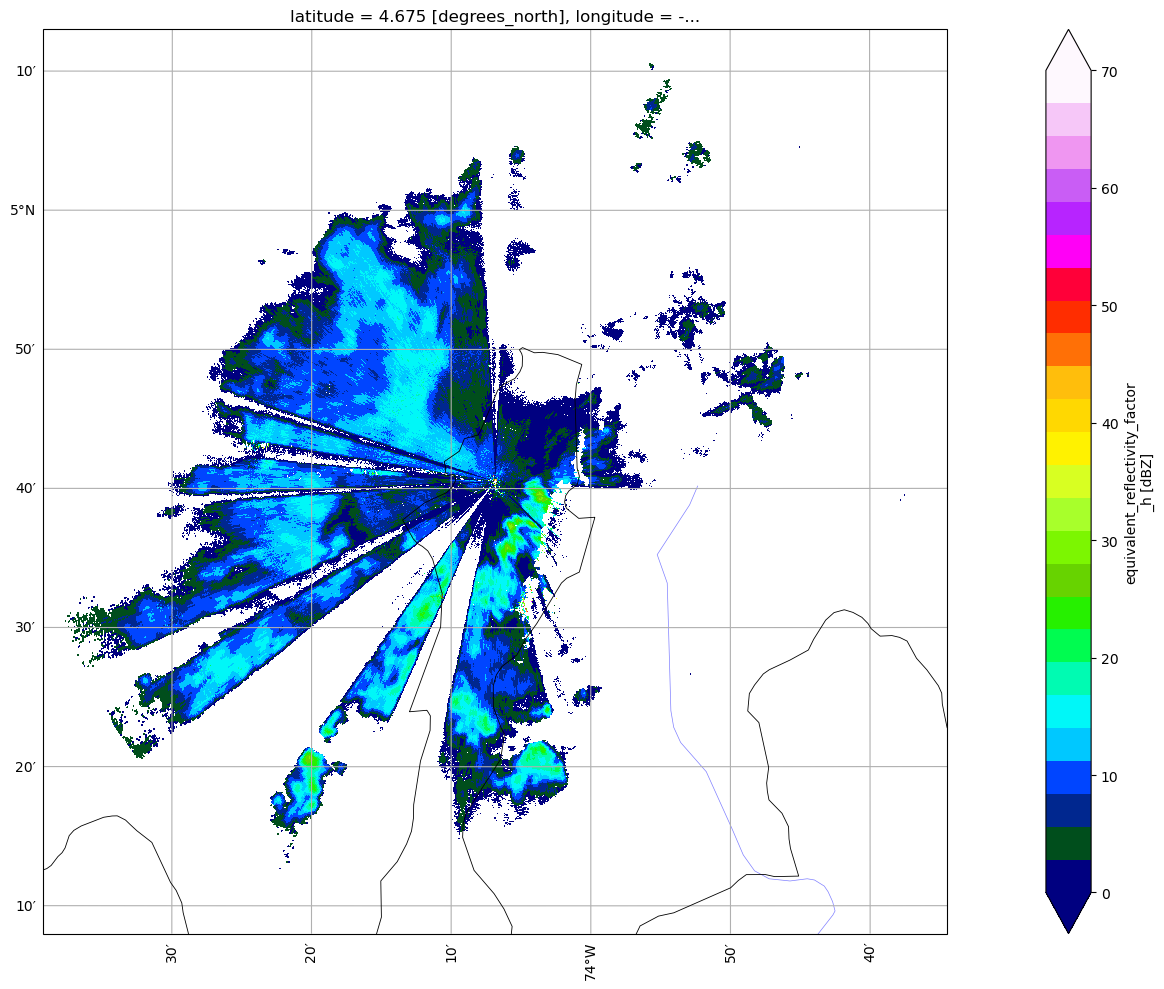

In [321]:
da = swp[f"{var}"]

print(da)


da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [322]:
var = "cDBZH"

<xarray.DataArray 'cDBZH' (azimuth: 1560, range: 960)> Size: 6MB
array([[3.       , 1.       , 0.5      , ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [1.5      , 1.5      , 1.5      , ...,       nan,       nan,
              nan],
       [6.5963326, 5.692665 , 4.692665 , ...,       nan,       nan,
              nan],
       [4.5      , 3.       , 2.       , ...,       nan,       nan,
              nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.05768 0.2911 0.5191 ... 359.4 359.6 359.8
    time       (azimuth) float64 12kB 33.0 33.0 33.0 33.0 ... 33.0 33.0 33.0
    elevation  (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505 2.505
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
   

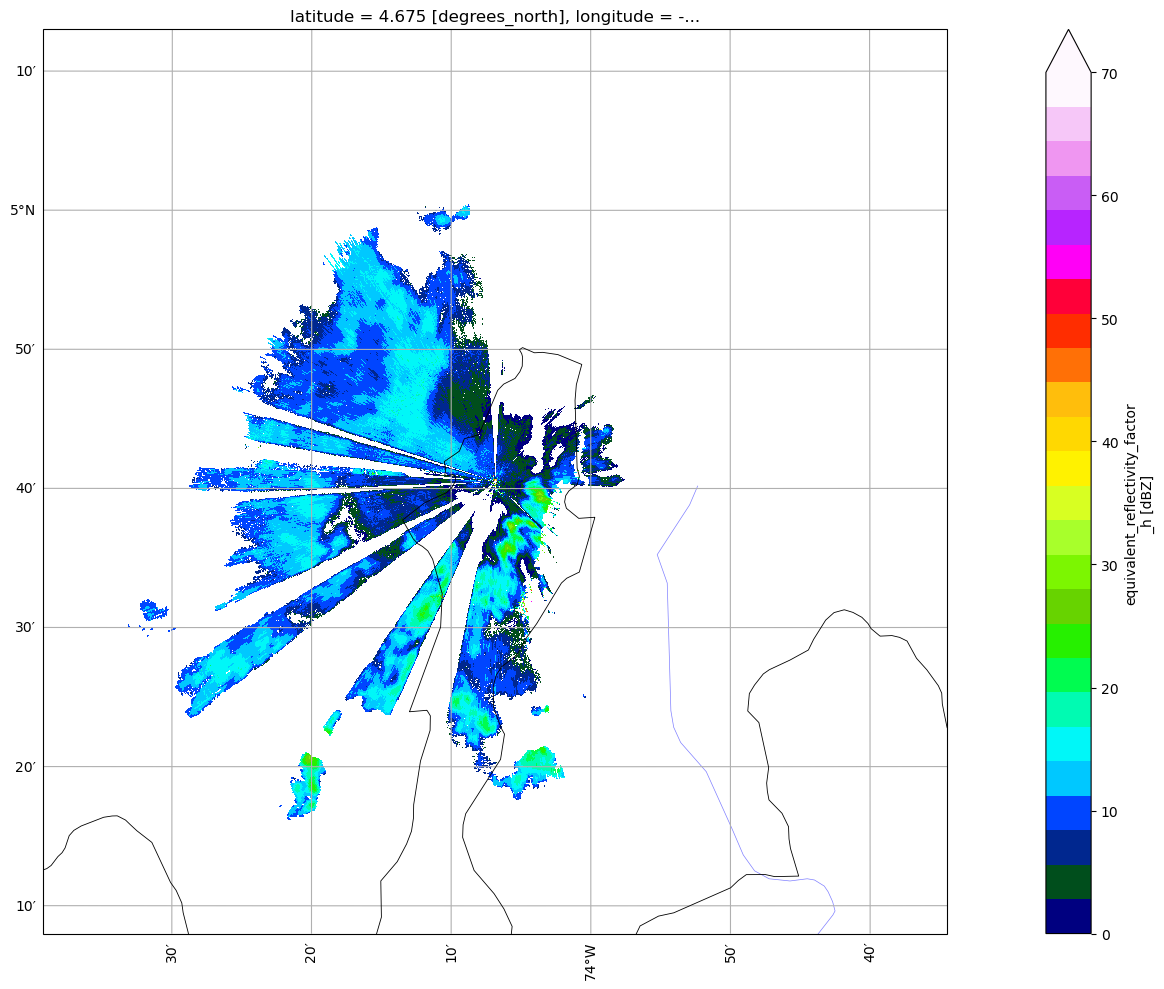

In [323]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [285]:
var = "RHOHV"

<xarray.DataArray 'RHOHV' (azimuth: 1560, range: 960)> Size: 6MB
array([[1.    , 1.    , 1.    , ..., 0.2588, 0.2588, 0.2588],
       [1.    , 1.    , 1.    , ..., 0.2588, 0.2588, 0.2787],
       [1.    , 1.    , 1.    , ..., 0.2588, 0.2588, 0.2588],
       ...,
       [0.9605, 0.9627, 0.9647, ..., 0.2588, 0.2588, 0.2588],
       [1.    , 1.    , 1.    , ..., 0.2588, 0.2787, 0.2588],
       [1.    , 1.    , 1.    , ..., 0.2981, 0.2981, 0.2981]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03
Attributes:
    long_name:  cross_correlation_ratio_hv
    units:      1


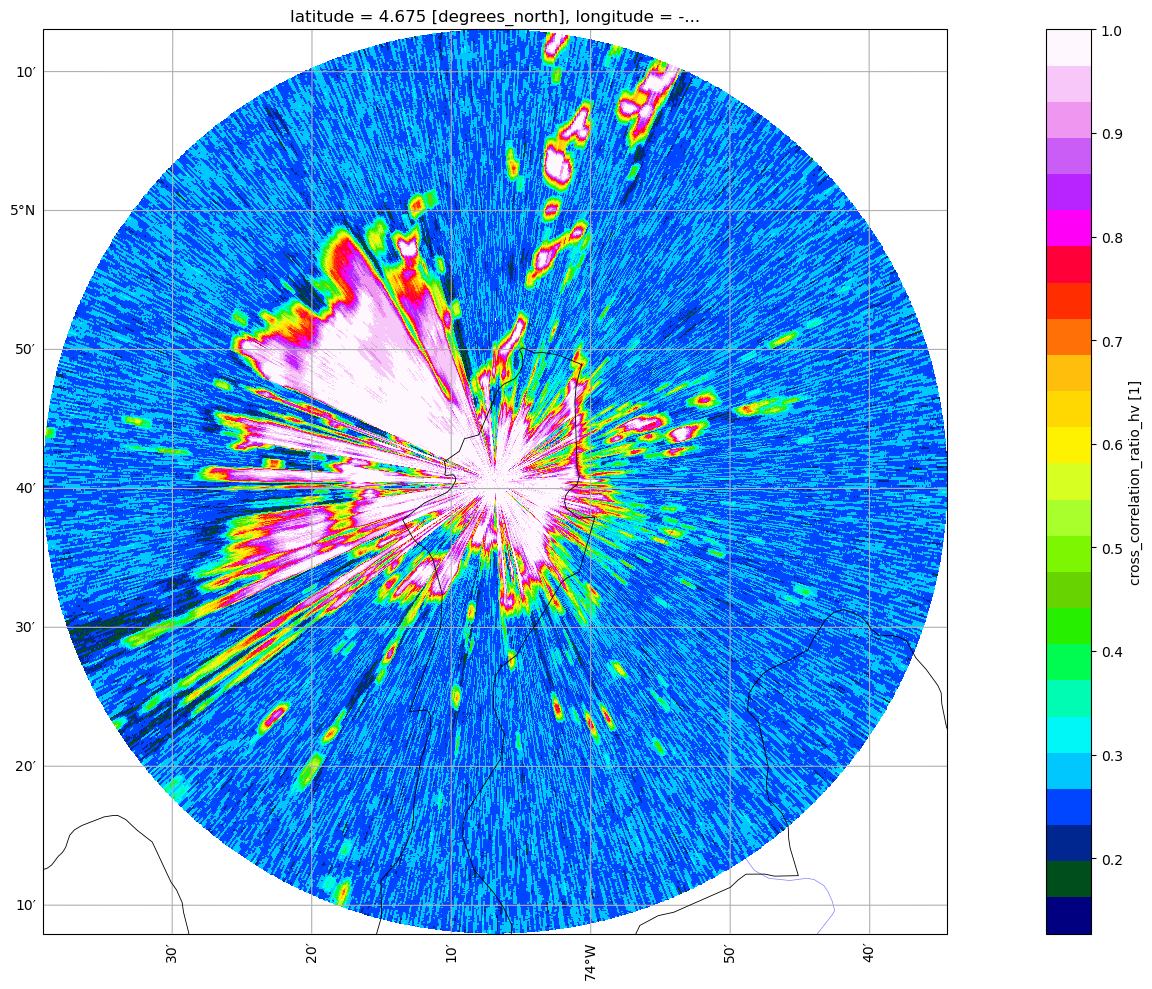

In [286]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [287]:
var = "SNRHC"

<xarray.DataArray 'SNRHC' (azimuth: 1560, range: 960)> Size: 6MB
array([[78.939995, 69.01    , 65.13    , ...,  0.43    ,  0.43    ,  0.43    ],
       [75.49    , 68.15    , 64.27    , ...,  0.86    ,  1.29    ,  0.43    ],
       [73.76    , 67.72    , 63.41    , ...,  0.43    ,  0.43    ,  0.43    ],
       ...,
       [73.76    , 62.539997, 57.37    , ...,  0.43    ,  0.43    ,  0.86    ],
       [72.9     , 60.82    , 56.07    , ...,  0.43    ,  0.43    ,  0.43    ],
       [76.78    , 64.7     , 59.96    , ...,  0.43    ,  0.43    ,  0.43    ]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   

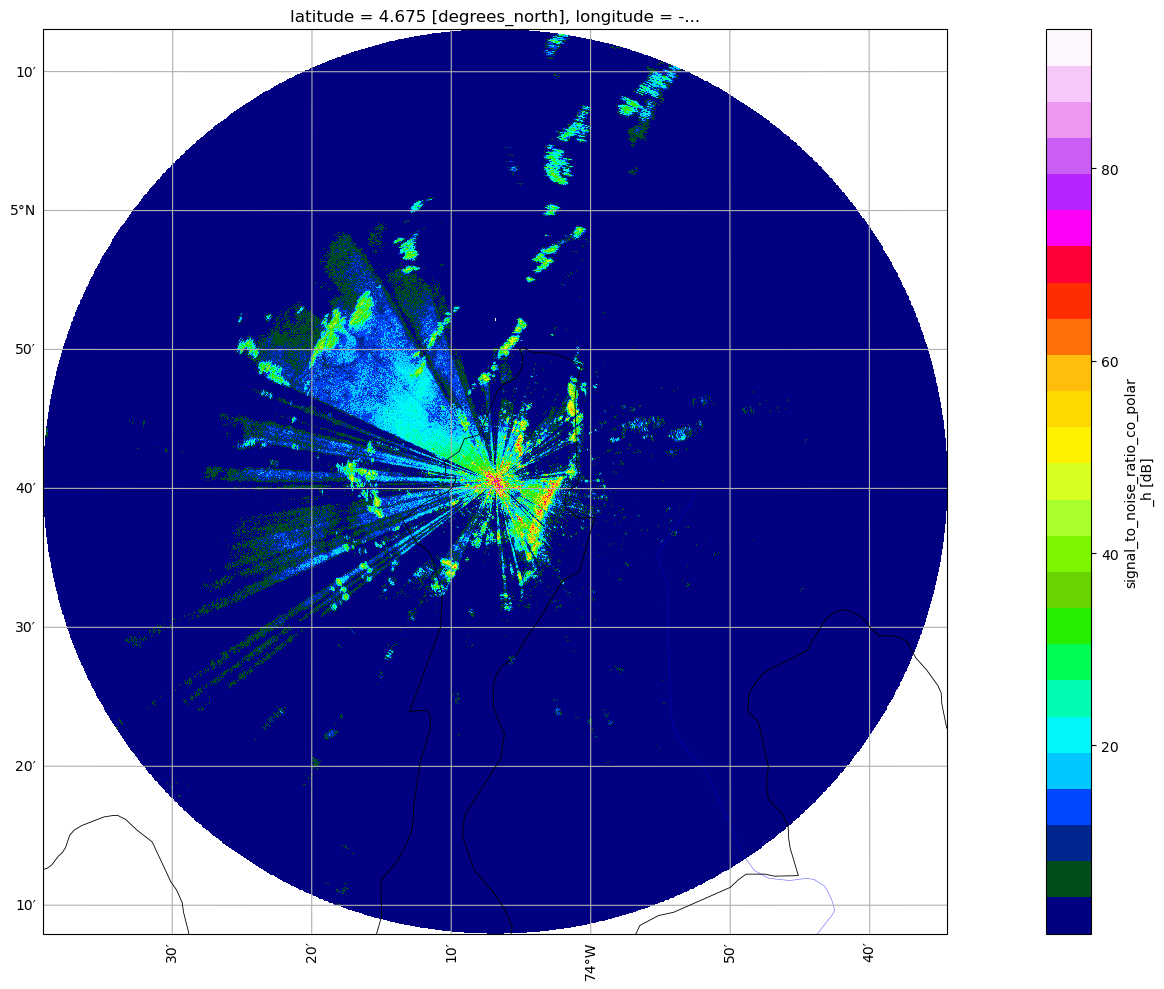

In [288]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [289]:
var = "PHIDP"

<xarray.DataArray 'PHIDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[  99.52    ,  130.58    ,  136.22    , ..., -106.579994, -106.579994,
        -120.7     ],
       [ 130.58    ,  161.64    ,  163.04    , ...,  -85.4     ,  -64.22    ,
         -82.58    ],
       [-115.04    , -132.      , -133.4     , ..., -123.52    ,  -47.28    ,
         -76.939995],
       ...,
       [  38.82    ,   40.219997,   31.76    , ..., -124.939995, -144.7     ,
        -124.939995],
       [  20.46    ,   10.58    ,   -0.7     , ..., -130.58    ,  -85.4     ,
        -117.88    ],
       [  62.82    ,   93.88    ,  103.759995, ..., -117.88    ,  -72.7     ,
        -117.88    ]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93

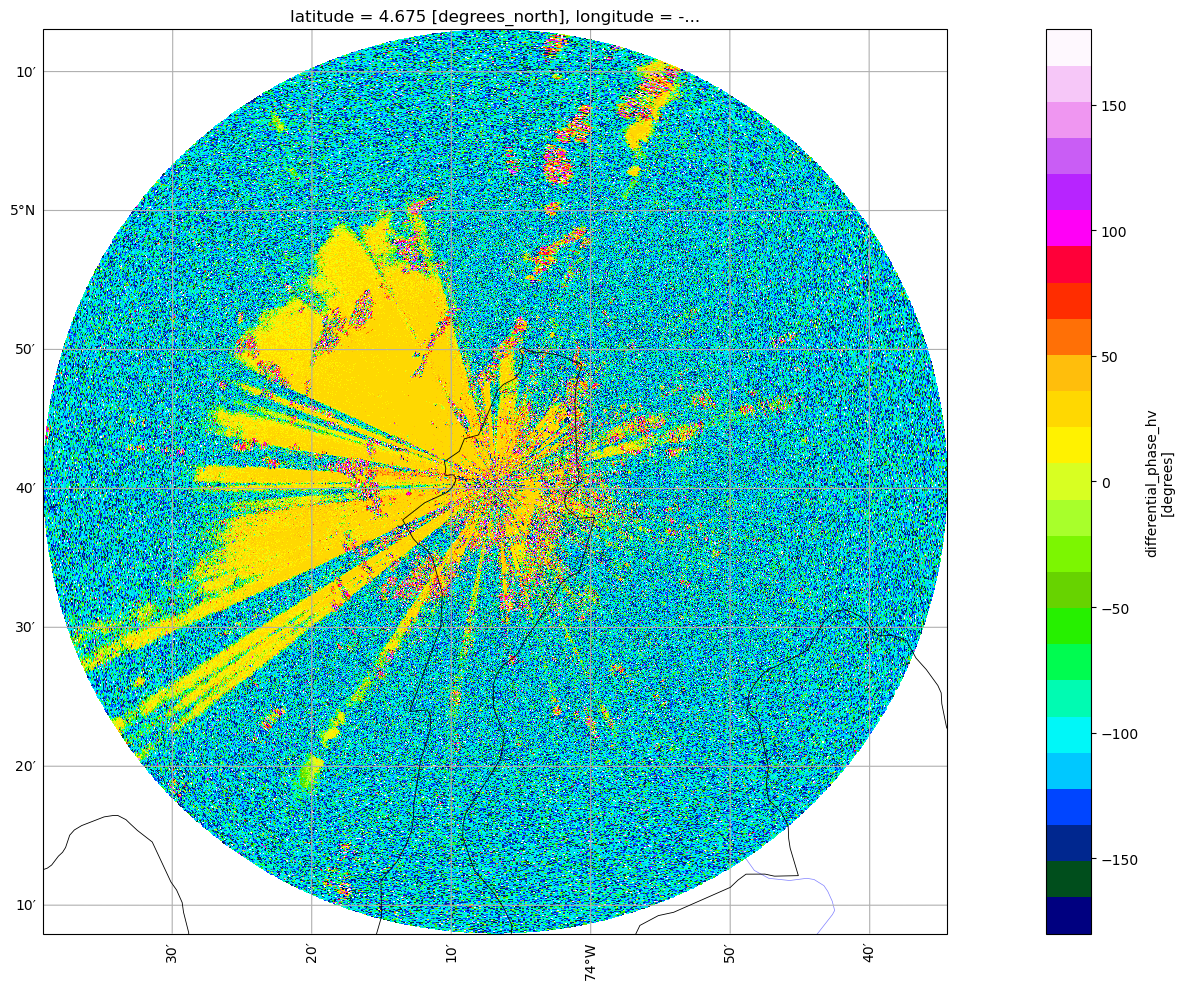

In [290]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [291]:
var = "fPHIDP"

<xarray.DataArray 'fPHIDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [38.637566, 38.637566, 38.637566, ...,       nan,       nan,
              nan],
       [16.862518, 16.862518, 16.862518, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    l

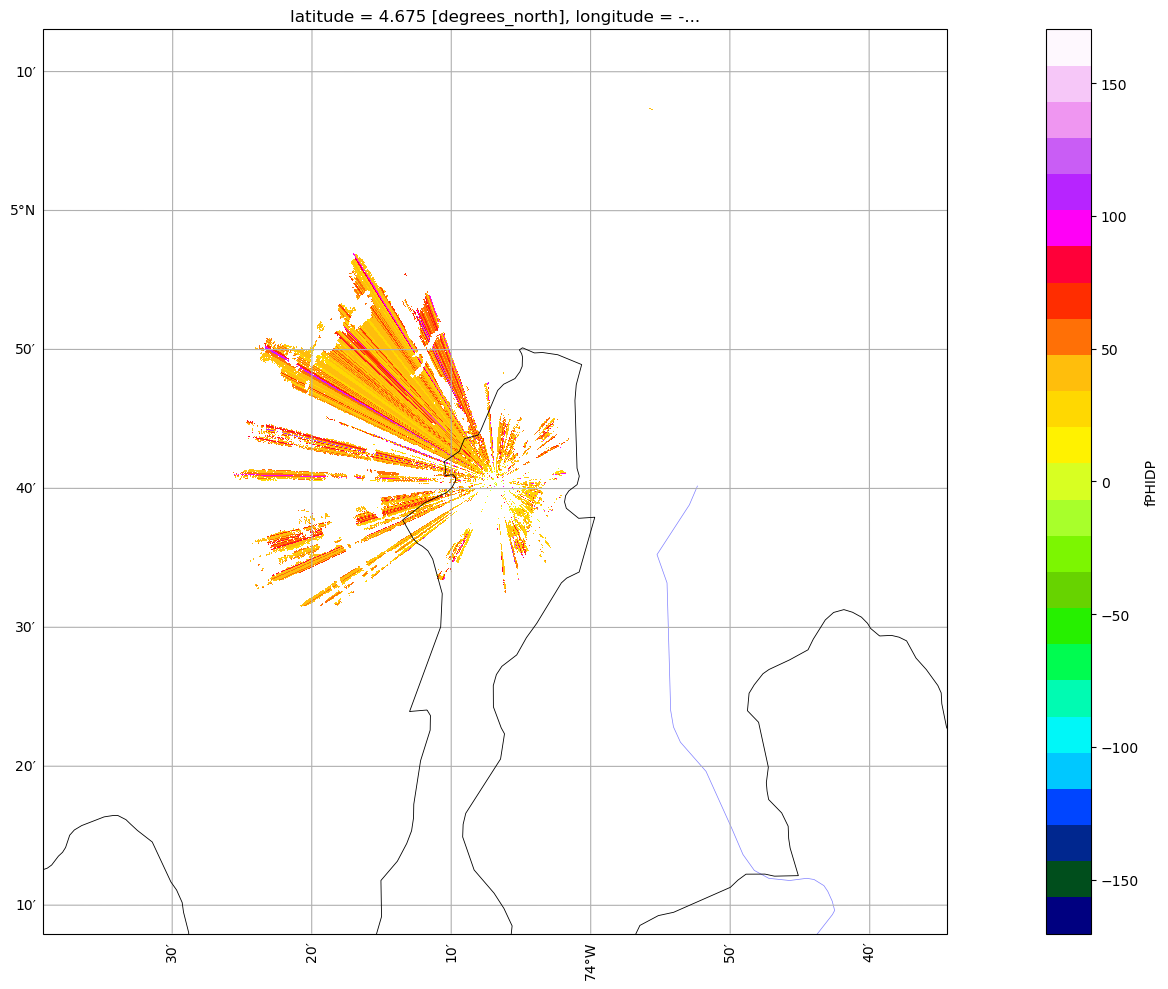

In [292]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [293]:
var = "cKDP"

<xarray.DataArray 'cKDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03
Attributes:
    long_name:  specific_differential_phase_hv
    units:      degrees/km


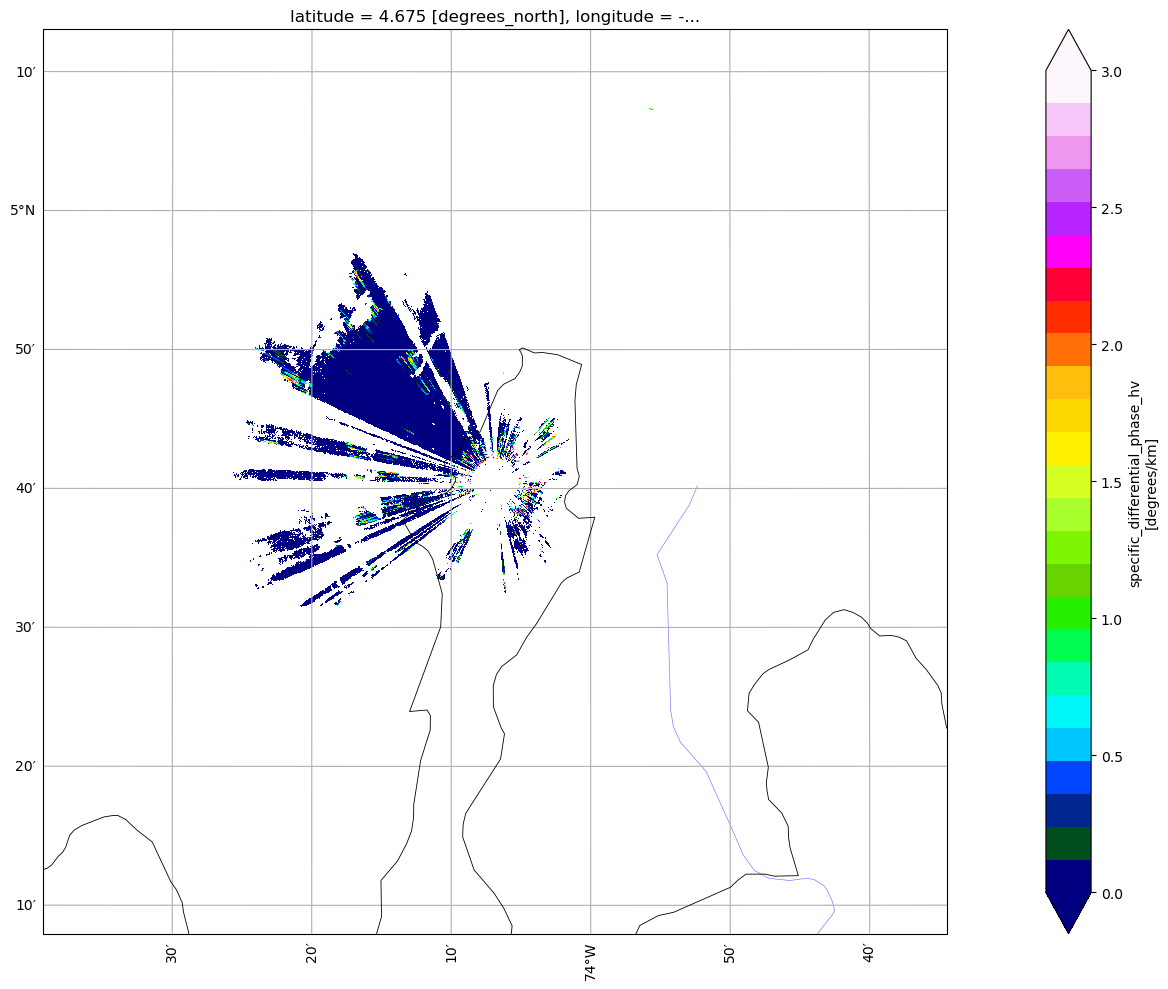

In [294]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=3,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [295]:
var = "dKDP"

<xarray.DataArray 'dKDP' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03


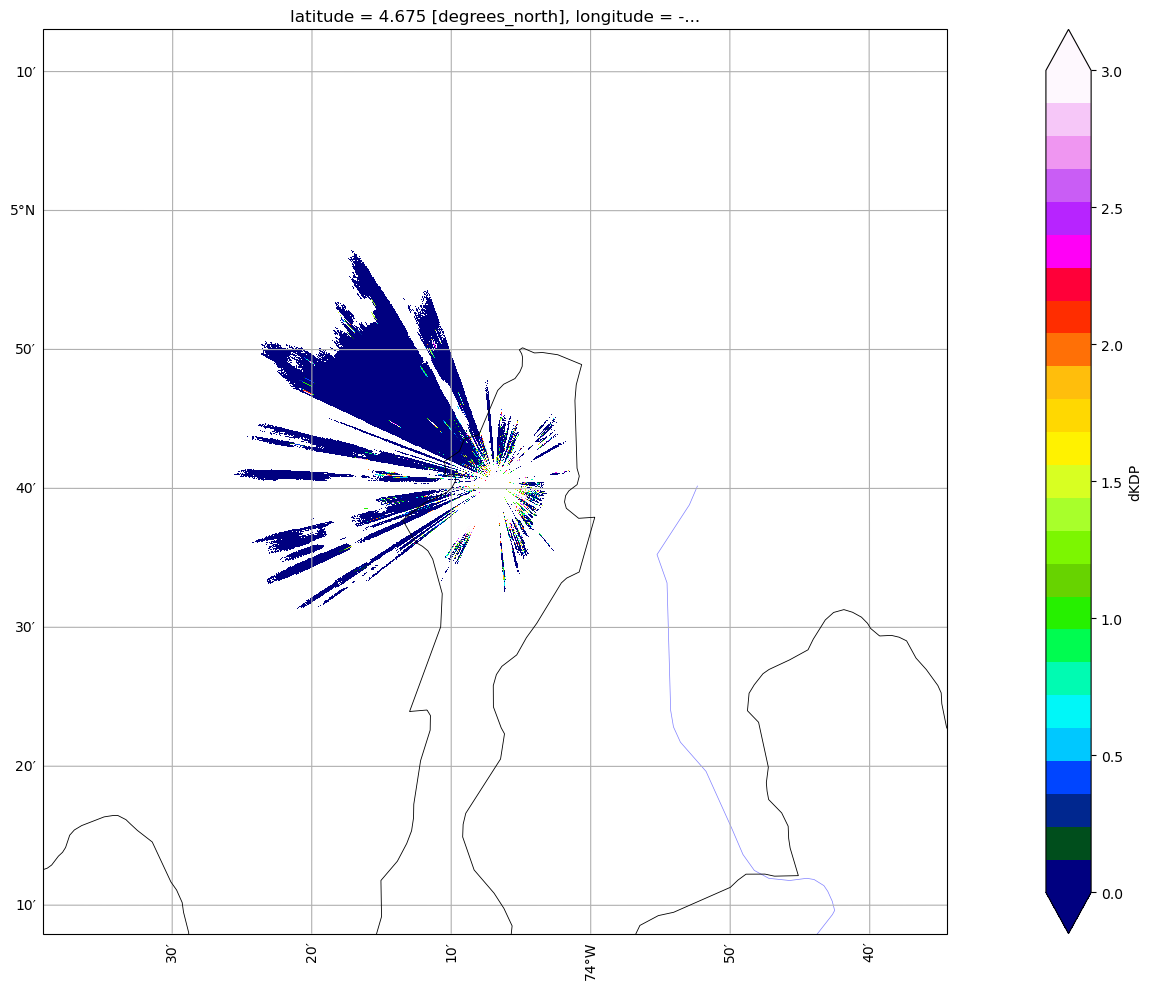

In [296]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=3,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [297]:
var = "R_A"

<xarray.DataArray 'R_A' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    longitude  float64 8B -74.11
    altitude   float64 8B 2.57e+03


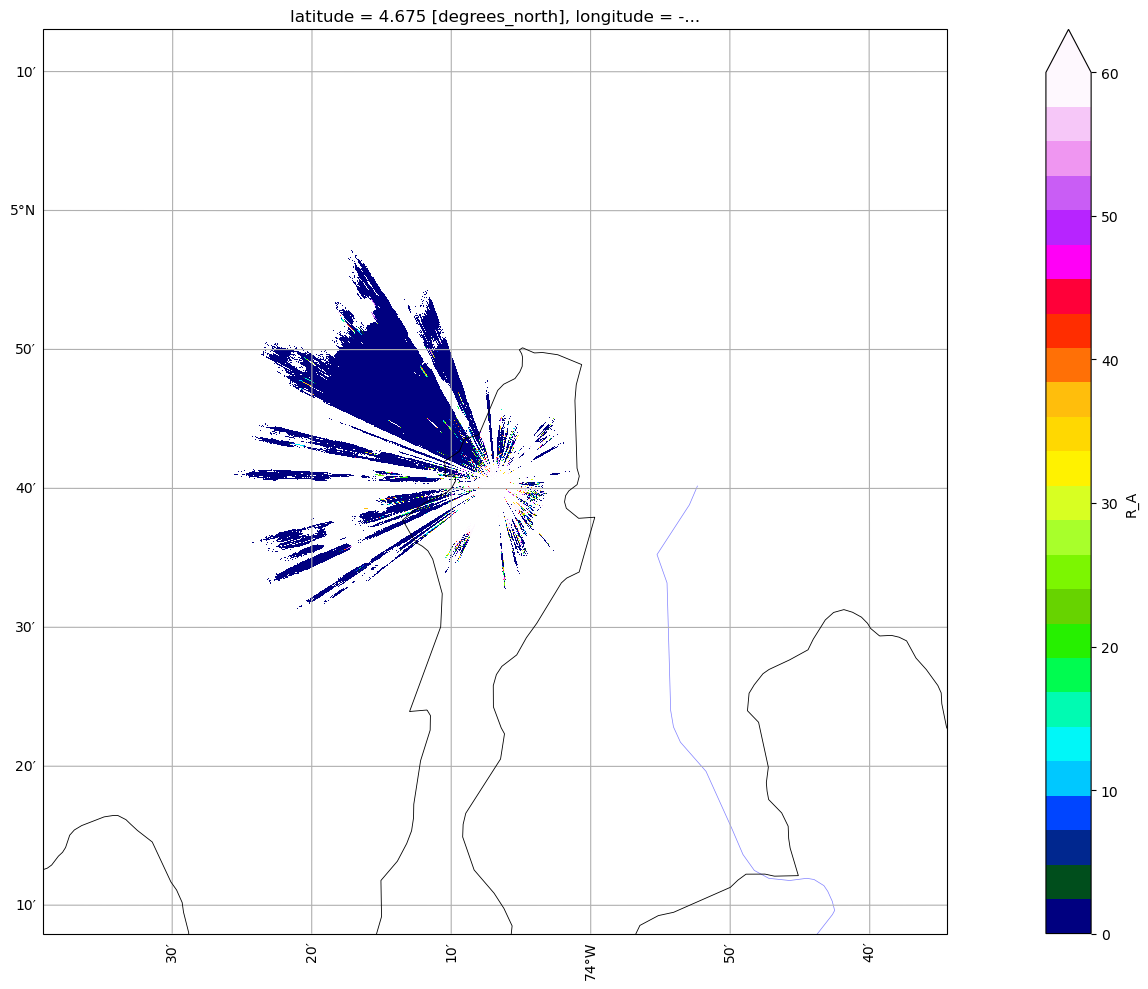

In [298]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [299]:
var= "R_Z"

<xarray.DataArray 'R_Z' (azimuth: 1560, range: 960)> Size: 6MB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.26204953, 0.28843635, 0.19650938, ...,        nan,        nan,
               nan],
       [0.08286733, 0.05129205, 0.03174803, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.184 0.4147 0.6454 ... 359.5 359.7 360.0
    time       (azimuth) float64 12kB 26.0 26.0 26.0 26.0 ... 26.0 26.0 26.0
    elevation  (azimuth) float32 6kB 0.5054 0.5054 0.5054 ... 0.5054 0.5054
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    

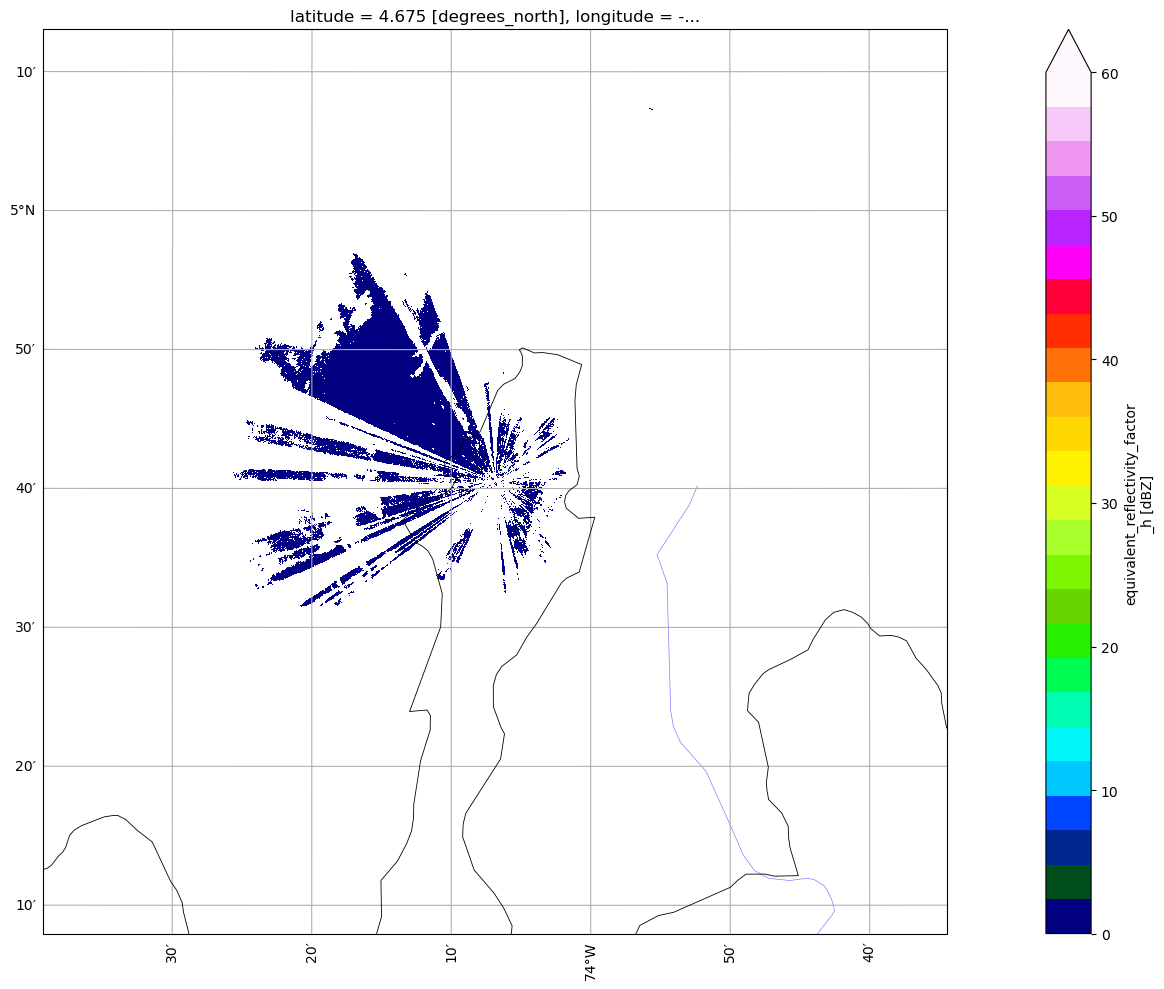

In [300]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [301]:
lat = dtree.latitude.values
lon = dtree.longitude.values
max_range = swp.range.values[-1]/1e3/111

max_lat = lat + max_range
max_lon = lon + max_range
min_lat = lat - max_range
min_lon = lon - max_range

In [ ]:
from sodapy import Socrata
import datetime as dt
import pandas as pd

TOKEN = ""

def download_data(date_init: dt.datetime, date_end: dt.datetime) -> pd.DataFrame:
    client = Socrata("www.datos.gov.co", TOKEN)

    date_init = pd.Timestamp(date_init).tz_localize('UTC').tz_convert('America/Bogota')
    date_end  = pd.Timestamp(date_end).tz_localize('UTC').tz_convert('America/Bogota')

    query = client.get(
        dataset_identifier = "s54a-sgyg",
        select             = "codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida",
        where              = f"fechaobservacion >= '{date_init.strftime('%Y-%m-%d')}' AND fechaobservacion < '{date_end.strftime('%Y-%m-%d')}'"
                             f"AND latitud > '{min_lat}' AND latitud < '{max_lat}' AND longitud > '{min_lon}' AND longitud < '{max_lon}'",
        limit              = 50000000,
    )

    data = pd.DataFrame.from_records(query)

    return data

In [303]:
time_arr = dtree["time_coverage_start"].values
time_str = time_arr.item().decode('utf-8')
time_pd = pd.to_datetime(time_str)  

start_utc = time_pd - pd.Timedelta(minutes=5)
end_utc   = time_pd + pd.Timedelta(minutes=4)
print(start_utc)
print(end_utc)

df = download_data(dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day),
                   dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day +1+1)) # a dia 12/05/2026 no funciona del tot correctament i has de posar un dia més perquè et retorni el dia que pertoca
print(df)

2024-10-22 00:00:45+00:00
2024-10-22 00:09:45+00:00
      codigoestacion         fechaobservacion   latitud    longitud  \
0         0021206890  2024-10-21T00:00:00.000   4.66577   -74.02861   
1         2120700037  2024-10-21T00:00:00.000  4.556439  -74.125173   
2         2120000134  2024-10-21T00:00:00.000   4.55257   -74.08373   
3         2120000172  2024-10-21T00:00:00.000   4.75947   -74.02752   
4         2120000131  2024-10-21T00:00:00.000     4.545   -74.13944   
...              ...                      ...       ...         ...   
36117     3502500135  2024-10-22T23:57:00.000   4.22553   -73.81481   
36118     3502500135  2024-10-22T23:58:00.000   4.22553   -73.81481   
36119     3502500135  2024-10-22T23:58:00.000   4.22553   -73.81481   
36120     3502500135  2024-10-22T23:59:00.000   4.22553   -73.81481   
36121     3502500135  2024-10-22T23:59:00.000   4.22553   -73.81481   

      valorobservado unidadmedida  
0                  0           mm  
1                  0   

In [181]:
df["fechaobservacion"] = (
    pd.to_datetime(df["fechaobservacion"])
    .dt.tz_localize("America/Bogota")
    .dt.tz_convert("UTC")
)
print(df)

      codigoestacion          fechaobservacion   latitud    longitud  \
0         0021206890 2024-10-21 05:00:00+00:00   4.66577   -74.02861   
1         2120700037 2024-10-21 05:00:00+00:00  4.556439  -74.125173   
2         2120000134 2024-10-21 05:00:00+00:00   4.55257   -74.08373   
3         2120000172 2024-10-21 05:00:00+00:00   4.75947   -74.02752   
4         2120000131 2024-10-21 05:00:00+00:00     4.545   -74.13944   
...              ...                       ...       ...         ...   
36117     3502500135 2024-10-23 04:57:00+00:00   4.22553   -73.81481   
36118     3502500135 2024-10-23 04:58:00+00:00   4.22553   -73.81481   
36119     3502500135 2024-10-23 04:58:00+00:00   4.22553   -73.81481   
36120     3502500135 2024-10-23 04:59:00+00:00   4.22553   -73.81481   
36121     3502500135 2024-10-23 04:59:00+00:00   4.22553   -73.81481   

      valorobservado unidadmedida  
0                  0           mm  
1                  0           mm  
2                  0       

In [182]:
utc_start = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day}", tz="UTC") 
utc_end   = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day + 1}", tz="UTC")
print(utc_start)
print(utc_end)

date_filtered_df = df[df["fechaobservacion"].between(utc_start, utc_end)]

print(date_filtered_df)

time_utc_start = pd.Timestamp(f"{start_utc.hour}:{start_utc.minute}:00", tz="UTC").time()
time_utc_end   = pd.Timestamp(f"{end_utc.hour}:{end_utc.minute}:00", tz="UTC").time()
time_filtered_df = date_filtered_df[date_filtered_df["fechaobservacion"].dt.time.between(time_utc_start, time_utc_end)]

print(time_filtered_df)

2024-10-22 00:00:00+00:00
2024-10-23 00:00:00+00:00
      codigoestacion          fechaobservacion      latitud       longitud  \
29266     0035060210 2024-10-22 01:10:00+00:00      4.65025   -73.64144444   
29267     0035060210 2024-10-22 01:10:00+00:00      4.65025   -73.64144444   
29268     0035060210 2024-10-22 01:20:00+00:00      4.65025   -73.64144444   
29269     0035060210 2024-10-22 01:20:00+00:00      4.65025   -73.64144444   
29270     0035060210 2024-10-22 01:30:00+00:00      4.65025   -73.64144444   
...              ...                       ...          ...            ...   
34773     3502500135 2024-10-23 00:00:00+00:00      4.22553      -73.81481   
34774     2120500204 2024-10-23 00:00:00+00:00  4.621556111  -74.104708889   
34775     3502500135 2024-10-23 00:00:00+00:00      4.22553      -73.81481   
34776     0035027001 2024-10-23 00:00:00+00:00  4.403388889   -73.94055556   
34777     0023065120 2024-10-23 00:00:00+00:00  5.141555556   -74.13936111   

      valor

In [183]:
filtered_df = time_filtered_df

In [184]:
print(np.unique_counts(filtered_df["codigoestacion"]))

UniqueCountsResult(values=array([], dtype=object), counts=array([], dtype=int64))


In [185]:
filtered_df["valorobservado"] = pd.to_numeric(filtered_df["valorobservado"].astype(float)*6, errors="coerce")
df = df.dropna(subset=["valorobservado"])

filtered_df["latitud"] = pd.to_numeric(filtered_df["latitud"], errors="coerce")
df = df.dropna(subset=["latitud"])

filtered_df["longitud"] = pd.to_numeric(filtered_df["longitud"], errors="coerce")
df = df.dropna(subset=["longitud"])

print(filtered_df)

Empty DataFrame
Columns: [codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida]
Index: []


In [186]:
var="R_Z"
number_of_colors=25

<xarray.DataArray 'R_Z' (azimuth: 1560, range: 960)> Size: 6MB
array([[21.629673, 16.219963, 13.388028, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 6kB 0.1291 0.3598 0.5905 ... 359.4 359.7 359.9
    time       (azimuth) float64 12kB 31.0 31.0 31.0 31.0 ... 31.0 31.0 31.0
    elevation  (azimuth) float32 6kB 2.505 2.505 2.505 ... 2.505 2.505 2.505
  * range      (range) float32 4kB 31.25 93.75 156.2 ... 5.991e+04 5.997e+04
    latitude   float64 8B 4.675
    lo

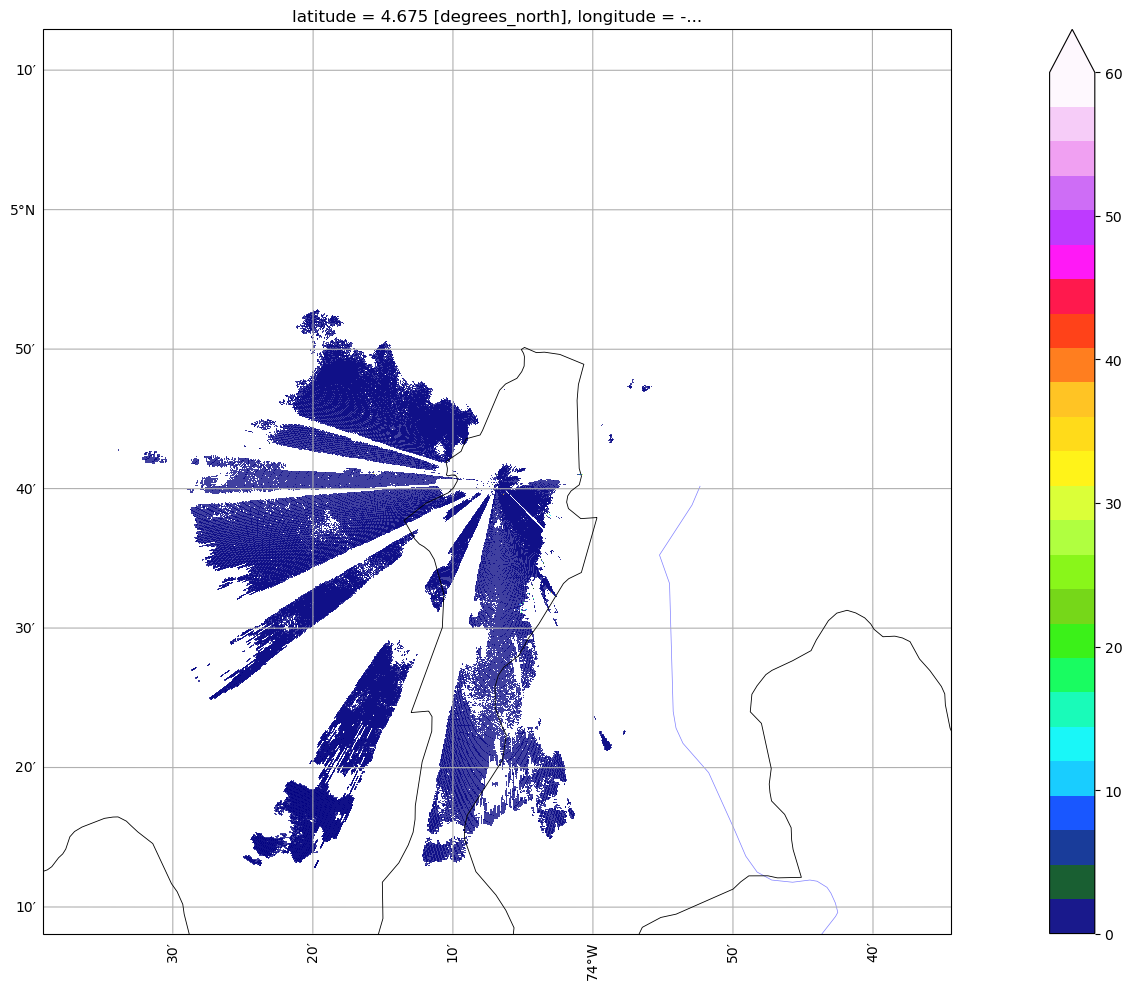

In [187]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
    alpha=0.75
)

filtered_df = filtered_df.dropna(subset=["longitud", "latitud", "valorobservado"])

print(f"Plotting {len(filtered_df)} points")
print(f"Lon range: {filtered_df['longitud'].min():.4f} to {filtered_df['longitud'].max():.4f}")
print(f"Lat range: {filtered_df['latitud'].min():.4f} to {filtered_df['latitud'].max():.4f}")

# ---- Center projection on the data ----
center_lon = filtered_df["longitud"].mean()
center_lat = filtered_df["latitud"].mean()

# ---- Map features ----
department_lines = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    edgecolor='black',
    facecolor='never',
    linewidth=0.6
)

# ---- Separar según valor observado ----
zeros = filtered_df[filtered_df["valorobservado"] == 0]
nonzeros = filtered_df[filtered_df["valorobservado"] > 0]

# ---- Dibujar puntos con precipitación >0 (relleno con colormap) ----
sc = ax.scatter(
    nonzeros["longitud"],
    nonzeros["latitud"],
    c=nonzeros["valorobservado"],
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    s=50,
    edgecolors="red",
    linewidth=0.9,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
)

# ---- Dibujar puntos con valor == 0 (solo borde, sin relleno) ----
ax.scatter(
    zeros["longitud"],
    zeros["latitud"],
    facecolors="none",
    edgecolors="black",
    s=20,
    linewidth=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
)

cb = plt.colorbar(sc,ax=ax,extend="max")

# ---- Adjust map extent to data bounds with a small margin ----
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

In [188]:
from scipy.spatial import cKDTree
from pyproj import Transformer
print(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B ...
│       time_coverage_start  |S25 25B b'2024-10-22T00:38:40Z'
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B ...
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters
│       Di

In [97]:
radar_alt = float(dtree["/"]["altitude"].values)
radar_lon = float(dtree["/"]["longitude"].values)
radar_lat = float(dtree["/"]["latitude"].values)

site = (radar_lon, radar_lat, radar_alt)

azimuth   = swp["azimuth"].data
range     = swp["range"].data
elangle   = swp["elevation"].data

elangle = dtree.sweep_fixed_angle.values
print(elangle)

gauge_lats = df["latitud"].values
gauge_lons = df["longitud"].values

azimuth_2d, range_2d = np.meshgrid(azimuth, range, indexing='ij')
elevation_2d = np.broadcast_to(elangle[:,np.newaxis], azimuth_2d.shape)

xyz,aeqd = wrl.georef.polar.spherical_to_xyz(
    range_2d,
    azimuth_2d,
    elevation_2d,
    site,
)

x = xyz[...,0]
y = xyz[...,1]
z = xyz[...,2]

transformer = Transformer.from_crs(
    aeqd,
    "EPSG:4326",
    always_xy=True,
)
lon,lat = transformer.transform(x,y)
alt = z

radar_lon = np.squeeze(lon)
radar_lat = np.squeeze(lat)
radar_z = np.squeeze(z)

swp.coords["gate_latitude"] = (('azimuth', 'range'), radar_lat)
swp.coords["gate_longitude"] = (('azimuth', 'range'), radar_lon)
swp.coords["gate_height"] = (('azimuth', 'range'), radar_z)

print(dtree)
print(swp.data_vars)

[4.7]
<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B 2.57e+03
│       time_coverage_start  |S25 25B b'2024-10-22T02:01:57Z'
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B 4.7
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters

In [98]:
lon_gauge = filtered_df["longitud"].values
lat_gauge = filtered_df["latitud"].values

print(lon_gauge,lat_gauge)

[-73.81481    -73.81481    -73.81481    -73.81481    -73.81481
 -73.81481    -74.10470889 -73.64144444 -74.10470889 -73.64144444] [4.22553    4.22553    4.22553    4.22553    4.22553    4.22553
 4.62155611 4.65025    4.62155611 4.65025   ]


In [99]:
gate_lon = swp['gate_longitude'].values
gate_lat = swp['gate_latitude'].values 

radar_precip = swp['R_A'].values

In [101]:
gate_points = np.column_stack([gate_lon.ravel(), gate_lat.ravel()])
tree = cKDTree(gate_points)

gauge_coords = filtered_df[['longitud', 'latitud']].values
distances, indices = tree.query(gauge_coords, k=1)

n_az = gate_lon.shape[0]
n_rng = gate_lon.shape[1]
az_idx = indices // n_rng
rng_idx = indices % n_rng

In [102]:
radar_vals = radar_precip[az_idx, rng_idx]

radar_vals = radar_precip[az_idx, rng_idx]

# Add to station dataframe
filtered_df['radar_precip'] = radar_vals
filtered_df['distance_to_radar_gate_m'] = distances 

In [103]:
# e.g., discard stations farther than 1 km from nearest gate (adjust threshold)
filtered_df = filtered_df[filtered_df['distance_to_radar_gate_m'] < 240000] 

/tmp/ipykernel_5150/3766909635.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


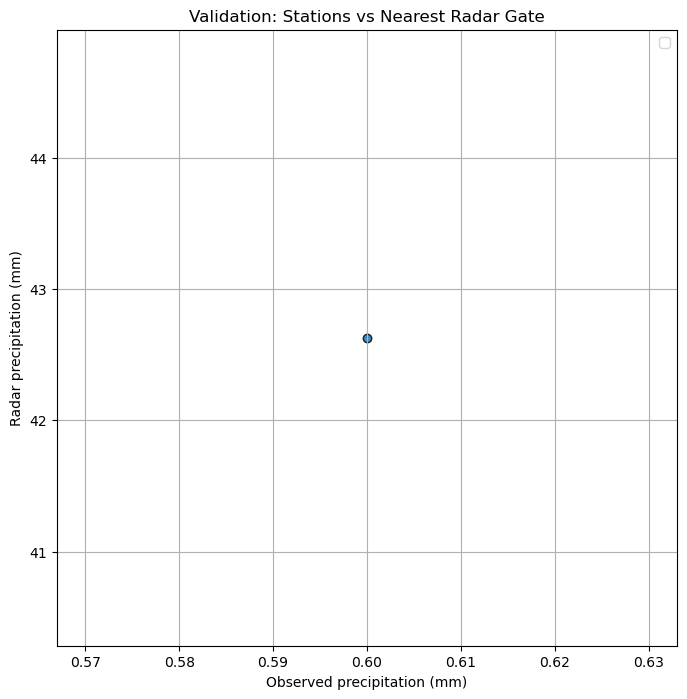

In [104]:
# Keep rows where both are > 0 (or >= some threshold)
#rain = df_obs[(df_obs['valorobservado'] > 0) & (df_obs['radar_precip'] > 0)]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(filtered_df['valorobservado'], filtered_df['radar_precip'], alpha=0.6, edgecolors='k')
#max_val = max(filtered_df['valorobservado'].max(), filtered_df['radar_precip'].max())
#ax.plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
ax.set_xlabel('Observed precipitation (mm)')
ax.set_ylabel('Radar precipitation (mm)')
ax.set_title('Validation: Stations vs Nearest Radar Gate')
ax.grid(True)
ax.legend()
plt.show()

In [105]:
import rioxarray

In [106]:
gate_latitude  = swp.coords["gate_latitude"].values
gate_longitude = swp.coords["gate_longitude"].values
gate_height    = swp.coords["gate_height"].values

In [107]:
import numpy as np
import rioxarray
from scipy.interpolate import interpn

dem_filepath = "GMTED2010S10W090_075/10s090w_20101117_gmted_mea075.tif"

# 1. Carregar el DEM i extreure els vectors de l'eix X (longitud) i Y (latitud)
dem = rioxarray.open_rasterio(dem_filepath, mask_and_scale=True).squeeze()
dem_lon = dem.x.values
dem_lat = dem.y.values

# Si les latituds van de nord a sud (valors decreixents), invertim l'eix i la matriu 
# perquè interpn necessita obligatòriament vectors estrictament creixents
if dem_lat[0] > dem_lat[-1]:
    dem_lat = dem_lat[::-1]
    dem_values = dem.values[::-1, :]
else:
    dem_values = dem.values

# 2. Interpola directament sobre la teva malla polar del radar (en NumPy pur)
# Creem la llista de punts de destinació on vols extreure l'elevació
punts_radar = np.stack((gate_latitude, gate_longitude), axis=-1)

# Executem la interpolació lineal (fora dels límits del DEM assignarà un valor de 0.0)
terrain_height = interpn(
    (dem_lat, dem_lon), 
    dem_values, 
    punts_radar, 
    method="linear", 
    bounds_error=False, 
    fill_value=0.0
)

# 3. Eliminar qualsevol valor nul residual (NaN)
terrain_height = np.nan_to_num(terrain_height, nan=0.0)



In [121]:
beamwidth = float(dtree["radar_parameters"]["radar_beam_width_h"].values)

r_distances = swp.coords["range"].values

beamradius = wrl.util.half_power_radius(r_distances, beamwidth)

pbb = wrl.qual.beam_block_frac(terrain_height, gate_height, beamradius)
cbb = wrl.qual.cum_beam_block_frac(np.ma.masked_invalid(pbb))

cbb_clean = np.ma.filled(cbb, fill_value=0.0)

print(cbb_clean)

swp["CBB"] = xr.DataArray(cbb_clean, dims=["azimuth", "range"])

swp["CBB"].attrs["long_name"] = "Cumulative Beam Blockage Fraction"
swp["CBB"].attrs["units"] = "1"
swp["CBB"].attrs["comment"] = "Calculat usant DEM GMTED2010 a 250m"


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in sqrt
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)
/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in arcsin
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)


In [125]:
dbzh_original = swp["DBZH"].values
cbb_data = swp["CBB"].values
print(cbb_data)

dbzh_corregit = np.copy(dbzh_original)

mask_compensar = (cbb_data >= 0.1) & (cbb_data <= 0.5)

dbzh_corregit[mask_compensar] = dbzh_corregit[mask_compensar] - 10.0 * np.log10(1.0 - cbb_data[mask_compensar])

mask_eliminar = cbb_data > 0.5
dbzh_corregit[mask_eliminar] = np.nan

swp["DBZH_terrain_corrected"] = xr.DataArray(dbzh_corregit, dims=["azimuth", "range"])
swp["DBZH_terrain_corrected"].attrs["long_name"] = "Reflectivity corrected for beam blockage"
swp["DBZH_terrain_corrected"].attrs["units"] = "dBZ"

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [126]:
print(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 9.3e+09
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       latitude             float64 8B 4.675
│       longitude            float64 8B -74.11
│       altitude             float64 8B 2.57e+03
│       time_coverage_start  |S25 25B b'2024-10-22T02:01:57Z'
│       time_coverage_end    |S25 25B ...
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│       sweep_fixed_angle    (sweep) float32 4B 4.7
│   Attributes:
│       Conventions:      Cf/Radial instrument_parameters radar_parameters
│       title:            PPIVol
│       institution:      EEC
│       references:       EEC
│       source:           EDGE
│       history:          original
│       comment:          PPIVol
│       instrument_name:  1399BOG
│       site_name:        1399BOG
├── Group: /radar_parameters
│    

In [131]:
var="DBZH_terrain_corrected"

<xarray.DataArray 'DBZH_terrain_corrected' (azimuth: 1560, range: 960)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1560, 960), dtype=float32)
Coordinates:
  * azimuth         (azimuth) float32 6kB 0.05219 0.2829 0.5136 ... 359.6 359.8
    time            (azimuth) float64 12kB 14.0 14.0 14.0 ... 14.0 14.0 14.0
    elevation       (azimuth) float32 6kB 4.708 4.708 4.708 ... 4.708 4.708
  * range           (range) float32 4kB 31.25 93.75 ... 5.991e+04 5.997e+04
    gate_latitude   (azimuth, range) float64 12MB 4.675 4.676 ... 5.215 5.215
    gate_longitude  (azimuth, range) float64 12MB -74.11 -74.11 ... -74.12
    gate_height     (azimuth, range) float64 12MB 2.573e+03 ... 7.694e+03
    latitude        float64 8B 4.675
    longitude  

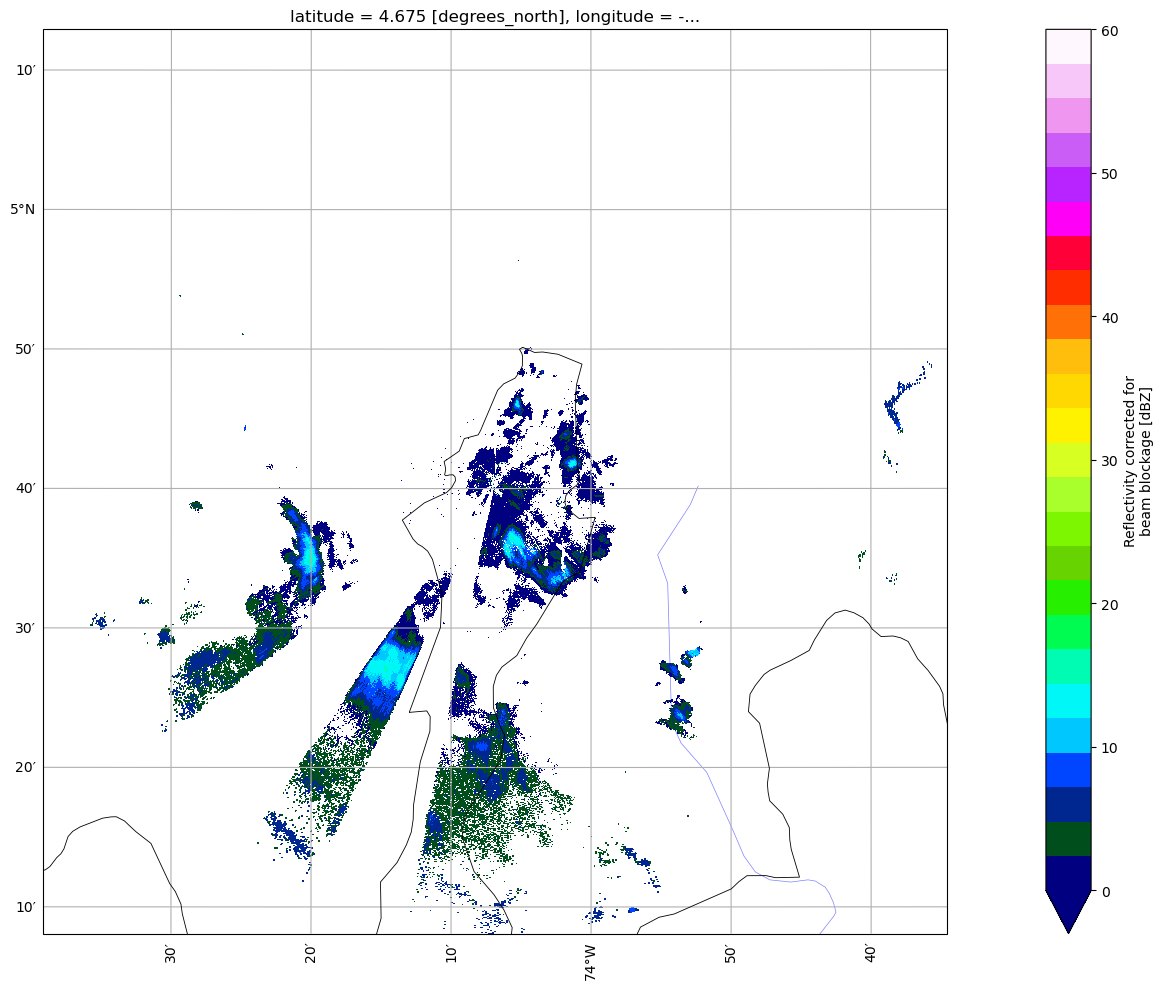

In [132]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()